# LexiLaw-NLP-Pipeline

**A Computational Pipeline for Diachronic Semantic Analysis of AI Governance Instruments (EU, US, Brazil, 2021-2025)**

This notebook is the executable reference implementation behind *A Computational Approach to Global AI Governance*
(submitted to *Machine Learning and Knowledge Extraction*, MDPI). It reproduces every table, figure, and similarity
matrix reported in the manuscript from the harmonized, pre-cleaned corpus (`*_LIMPOS.txt` files).

## How to use this notebook

Run the stages **in order, in a single uninterrupted session**. Each stage writes its artefacts to `outputs/` and
later stages may depend on variables created earlier in the same kernel. Do not skip cells or re-run them out of
order across sessions -- Colab kernels do not guarantee that variable state survives a disconnect, and several
stages (5 and 6) write to the same output filenames, so a partial or out-of-order run can leave stale files behind.

**Prerequisite.** This notebook assumes `*_LIMPOS.txt` files already exist under `corpus_dir` -- i.e. that
Stage 0 (raw-text cleaning and encoding normalization, `pipeline_2.py` in the repository root) has already been
run. That script is not included here; if `corpus_dir` is empty, run it first.

## Pipeline stages

| Stage | Purpose | Key outputs |
|---|---|---|
| 0 | Corpus manifest (token counts per document) | `prominencia_lexical_dirigida.csv` |
| 1 | Shared preprocessing definitions (CONCEPT_MAP, stoplists, lemmatizer) | -- |
| 2 | Topic-count selection: perplexity + coherence sweep, K = 2..10 | `lda_perplexity_plot.png` |
| 3 | Bootstrap stability validation of the K = 5 solution (30 iterations, 80% sub-sampling) | `resultado_estabilidade_lda.txt` |
| 4 | Final LDA model (K = 5): topic table, wordclouds, Sankey diagram | `wordclouds_lda.png`, `sankey_diagram.html` |
| 5 | Co-occurrence networks: dynamic edge-weight threshold, Louvain communities, radar chart | `network_complexity_metrics.csv`, `radar_chart_complexity.png` |
| 6 | Similarity metrics: Jaccard, Dice, TF-IDF cosine, Sentence-BERT cosine | `matriz_*_6x6.csv`, `heatmap_*.png` |
| 7 | Package all outputs into a single archive for download | `outputs.zip` |

## A note on known inconsistencies

This cleanup preserves the **exact computational logic** that produced the numbers currently reported in the
manuscript -- nothing here changes a single reported figure. In the process of documenting the pipeline, three
pre-existing inconsistencies became visible and are flagged inline, at the cell where they occur, rather than
silently fixed (fixing them would change results, which is out of scope for this pass):

1. **Stage 2 (K-selection) and Stage 3 (bootstrap validation) segment the corpus differently.** Stage 2 uses a
   legal-device regex split (`Article`/`Sec.`/`Section`/`CHAPTER`, paragraph fallback), yielding ~836 segments.
   Stage 3, whose segment/token counts match Table 1 of the manuscript, uses a simple newline/length split,
   yielding 12,589 segments. K = 5 was therefore selected on one corpus construction and stability-validated on
   a different one.
2. **Stage 4's final topic table and Stage 4's wordcloud/Sankey figures are trained on different stoplists /
   segmentations from each other**, and neither is guaranteed to reproduce Table 2 of the manuscript exactly --
   see the note in the Stage 4 cell.
3. **Stage 5/6 (networks and similarity) intentionally use a lighter preprocessing pass** (whitespace split on
   the `_LIMPOS.txt` files) than Stage 2-4 (full POS-tagged lemmatization + CONCEPT_MAP). This reproduces the
   published similarity/network numbers exactly, but means the topic model and the network/similarity analyses
   are not computed over an identical vocabulary. See the note in Stage 1.

These are recorded here as a single source of truth so that anyone extending this notebook knows what they are
inheriting, rather than rediscovering it from scratch.

## Environment Setup

Installs every third-party package used anywhere in this notebook, once, up front. The original pipeline
scattered `!pip install` calls across several cells (each installing only what that specific cell needed);
consolidating them here means a fresh runtime can be provisioned in one step instead of failing midway through
a later stage with a missing-package error.

In [1]:
!pip install -q \
    gensim \
    sentence-transformers \
    python-louvain \
    networkx \
    wordcloud \
    plotly \
    kaleido \
    scikit-learn \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.0 MB/s eta 0:00:00


## Stage 0 -- Environment and Corpus Manifest

Loads every `*_LIMPOS.txt` file in `corpus_dir`, reports raw whitespace-token counts per document, and writes a lexical-prominence manifest. This is a sanity check step: run it first to confirm the corpus is complete before any downstream stage.

In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd

# --- Reproducibility -------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Paths -------------------------------------------------------------
CORPUS_DIR = "/content/corpus"
OUTPUT_DIR = os.path.join(CORPUS_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def document_name(filename: str) -> str:
    """Normalize a '*_LIMPOS.txt' filename to its document key, e.g. 'BR_2023'."""
    return os.path.basename(filename).replace("_LIMPOS.txt", "").replace(" LIMPOS.txt", "")

limpos_files = sorted(glob.glob(os.path.join(CORPUS_DIR, "*LIMPOS.txt")))
if not limpos_files:
    raise FileNotFoundError(
        f"No '*_LIMPOS.txt' files found in {CORPUS_DIR}. "
        "Run the Stage-0 cleaning script (pipeline_2.py) first."
    )

raw_documents = {}
print("Corpus manifest (raw whitespace token counts):")
for filepath in limpos_files:
    name = document_name(filepath)
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    raw_documents[name] = text
    print(f"  {name:10s} | {os.path.basename(filepath):24s} | {len(text.split()):>7,d} tokens")

manifest = pd.DataFrame(
    [{"Documento": k, "Total_Tokens": len(v.split())} for k, v in raw_documents.items()]
)
manifest.to_csv(os.path.join(OUTPUT_DIR, "prominencia_lexical_dirigida.csv"), index=False)
print(f"\nManifest written to {OUTPUT_DIR}/prominencia_lexical_dirigida.csv")


Corpus manifest (raw whitespace token counts):
  BR_2023    | BR_2023 LIMPOS.txt       |   9,118 tokens
  BR_2025    | BR_2025_LIMPOS.txt       |  14,029 tokens
  EU_2021    | EU_2021_LIMPOS.txt       |  47,104 tokens
  EU_2024    | EU_2024_LIMPOS.txt       |  90,415 tokens
  EU_CTRL_NEG_ND_202 | EU_CTRL_NEG_ND_202_LIMPOS.txt |  40,232 tokens
  EU_CTRL_NEG_OUOD_DOMAIN_2019 | EU_CTRL_NEG_OUOD_DOMAIN_2019_LIMPOS.txt |  13,975 tokens
  US_2023    | US_2023_LIMPOS.txt       |  19,668 tokens
  US_2025    | US_2025_LIMPOS.txt       |  11,040 tokens

Manifest written to /content/corpus/outputs/prominencia_lexical_dirigida.csv


## Stage 1 -- Shared Preprocessing Definitions

Defines the CONCEPT_MAP (multi-word institutional-term unification), the stoplists, and the lemmatization
pipeline used by the topic-modeling stages (2-4).

> **Note on scope.** The network and similarity stages (5-6) do **not** call `preprocess_for_topic_modeling()`.
> They intentionally operate on lightly-processed tokens (lowercased whitespace splits of the `_LIMPOS.txt`
> files, optionally passed through `NETWORK_SIMILARITY_STOPLIST`) rather than the fully lemmatized,
> POS-tagged, CONCEPT_MAP-substituted vocabulary defined here. This preserves the exact similarity and network
> figures already reported in the manuscript. Harmonizing the two preprocessing tracks would change those
> numbers and is tracked as a follow-up, not done in this pass.

In [3]:
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

# --- Stoplists ---------------------------------------------------------
# Structural terms (legislative formatting / boilerplate).
STRUCTURAL_STOPWORDS = {
    "art", "article", "chapter", "section", "paragraph", "subparagraph", "inciso",
    "act", "law", "bill", "senate", "federal", "national", "congress", "shall", "may",
    "provided", "pursuant", "accordance", "terms", "page", "proposes", "leave",
    "secretary", "agency", "order", "security", "day", "within",
}
ROMAN_NUMERALS = {
    "i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x", "xi", "xii", "xiii",
    "xiv", "xv", "xvi", "xvii", "xviii", "xix", "xx", "xxi", "xxii", "xxiii", "xxiv",
    "xxv", "xxvi", "xxvii", "xxviii", "xxix", "xxx",
}
# Conceptual terms (high-frequency but semantically generic once CONCEPT_MAP has run).
CONCEPTUAL_STOPWORDS = {
    "use", "system", "artificial_intelligence_system", "artificial_intelligence",
    "include", "appropriate", "regulation", "person", "mean", "provision", "part",
}

# Used by Stage 2 (K-selection) and Stage 3 (bootstrap validation).
TOPIC_MODELING_STOPWORDS = (
    set(stopwords.words("english"))
    .union(ROMAN_NUMERALS)
    .union(STRUCTURAL_STOPWORDS)
)

# Used by Stage 5 (networks) and Stage 6 (similarity) -- see the scope note above.
NETWORK_SIMILARITY_STOPLIST = set(stopwords.words("english")).union(CONCEPTUAL_STOPWORDS).union({
    "provision", "paragraph", "section", "part", "chapter", "shall",
})

# --- CONCEPT_MAP: strict-precedence multi-word entity unification ------
CONCEPT_MAP = [
    (r"\bartificial[-\s]+intelligence[-\s]+high[-\s]+risk[-\s]+system(s)?\b", "high_risk_system"),
    (r"\bhigh[-\s]+risk[-\s]+ai[-\s]+system(s)?\b", "high_risk_system"),
    (r"\bhigh[-\s]+risk[-\s]+artificial[-\s]+intelligence[-\s]+system(s)?\b", "high_risk_system"),
    (r"\bartificial[-\s]+intelligence[-\s]+system(s)?\b", "artificial_intelligence_system"),
    (r"\bai[-\s]+system(s)?\b", "artificial_intelligence_system"),
    (r"\bhigh[-\s]+risk[-\s]+system(s)?\b", "high_risk_system"),
    (r"\bhigh[-\s]+risk\b", "high_risk"),
    (r"\bartificial[-\s]+intelligence\b", "artificial_intelligence"),
    (r"\balgorithmic[-\s]+impact[-\s]+assessment(s)?\b", "algorithmic_impact_assessment"),
    (r"\bregulatory[-\s]+sandbox(es)?\b", "regulatory_sandbox"),
    (r"\bgeneral[-\s]+purpose[-\s]+ai\b", "general_purpose_ai"),
    (r"\bai[-\s]+actor(s)?\b", "ai_actor"),
    (r"\bai[-\s]+provider(s)?\b", "ai_provider"),
    (r"\bai[-\s]+deployer(s)?\b", "ai_deployer"),
    (r"\bsynthetic[-\s]+content\b", "synthetic_content"),
    (r"\bgenerative[-\s]+ai\b", "generative_ai"),
    (r"\bhuman[-\s]+oversight\b", "human_oversight"),
    (r"\bai\b", "artificial_intelligence"),
]
PARENTHETICAL_ACRONYM_PATTERNS = [
    (r"\bartificial[-\s]+intelligence\s*\(\s*ai\s*\)", "artificial intelligence"),
    (r"\bhigh[-\s]+risk\s*\(\s*ai\s*\)\s*system(s)?\b", "high-risk ai system"),
]

LEMMATIZER = WordNetLemmatizer()

def _wordnet_pos(tag: str) -> str:
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_for_topic_modeling(text: str, stoplist: set = TOPIC_MODELING_STOPWORDS) -> list:
    """Lowercase -> CONCEPT_MAP substitution -> strip non-alpha -> POS-tag -> lemmatize -> stopword filter.

    Returns a list of cleaned, lemmatized tokens. Used exclusively by Stages 2-4 (topic modeling).
    """
    text = text.lower()
    for pattern, replacement in PARENTHETICAL_ACRONYM_PATTERNS:
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in CONCEPT_MAP:
        text = re.sub(pattern, replacement, text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-zA-Z_\s]", " ", text)

    tokens = text.split()
    if not tokens:
        return []
    try:
        tagged = pos_tag(tokens)
        cleaned = []
        for word, tag in tagged:
            if word in stoplist or len(word) <= 2:
                continue
            lemma = LEMMATIZER.lemmatize(word, _wordnet_pos(tag))
            if lemma not in stoplist:
                cleaned.append(lemma)
        return cleaned
    except Exception:
        return [LEMMATIZER.lemmatize(w) for w in tokens if w not in stoplist and len(w) > 2]

# Legal-device segmentation: split on Article/Sec./Section/CHAPTER/CAPITULO/paragraph mark,
# falling back to blank-line paragraph splitting for documents with fewer than 15 such units
# (used only by Stage 2 -- see the Stage-2/Stage-3 segmentation-mismatch note above).
LEGAL_DEVICE_SPLIT_REGEX = r"(?im)(?=^[ \t]*(?:Article|Art\.|Sec\.|Section|CHAPTER|CAPÍTULO|§)\s*\d+)"

def split_by_legal_device(raw_text: str) -> list:
    units = re.split(LEGAL_DEVICE_SPLIT_REGEX, raw_text)
    if len(units) < 15:
        units = re.split(r"\n\s*\n", raw_text)
    return units

print("Stage 1 definitions loaded: CONCEPT_MAP "
      f"({len(CONCEPT_MAP)} patterns), TOPIC_MODELING_STOPWORDS "
      f"({len(TOPIC_MODELING_STOPWORDS)} terms), NETWORK_SIMILARITY_STOPLIST "
      f"({len(NETWORK_SIMILARITY_STOPLIST)} terms).")


Stage 1 definitions loaded: CONCEPT_MAP (18 patterns), TOPIC_MODELING_STOPWORDS (256 terms), NETWORK_SIMILARITY_STOPLIST (213 terms).


## Stage 2 -- Topic-Count Selection (Perplexity vs. Coherence Sweep)

Segments the corpus by legal device (Article/Section/Chapter, paragraph fallback), trains an LDA model for
K = 2..10, and evaluates each with Perplexity (scikit-learn) and Semantic Coherence `C_v` (gensim). The
trade-off point (K = 5) is selected here; see Figure 1 in the manuscript.

> This corpus construction (legal-device segmentation, ~836 segments) is used **only** for this K-selection
> sweep. Stage 3's bootstrap validation of the chosen K = 5 solution runs on a differently-segmented corpus
> (see the note there). Both are preserved as-is to match the manuscript's reported figures; see the top-level
> "known inconsistencies" note.

Segments for K-selection sweep: 838
Evaluating Perplexity and Coherence for K = 2..10...
  K= 2 -> Perplexity:  1047.23 | Coherence (C_v): 0.4428
  K= 3 -> Perplexity:   974.61 | Coherence (C_v): 0.4361
  K= 4 -> Perplexity:   942.81 | Coherence (C_v): 0.4658
  K= 5 -> Perplexity:   939.89 | Coherence (C_v): 0.4835
  K= 6 -> Perplexity:   929.06 | Coherence (C_v): 0.4574
  K= 7 -> Perplexity:   933.61 | Coherence (C_v): 0.5325
  K= 8 -> Perplexity:   912.16 | Coherence (C_v): 0.4594
  K= 9 -> Perplexity:   923.71 | Coherence (C_v): 0.5189
  K=10 -> Perplexity:   907.48 | Coherence (C_v): 0.4901


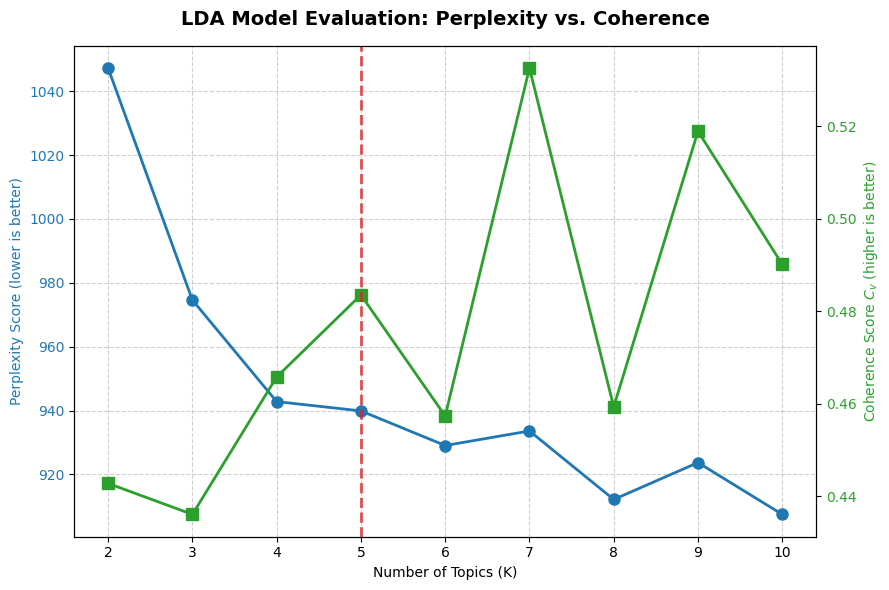

Saved: /content/corpus/outputs/lda_metrics_combined.png


In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

def load_segments_by_legal_device(corpus_dir, min_tokens=6):
    """Segment every '*_LIMPOS.txt' file by legal device and preprocess each unit
    with the full topic-modeling pipeline (Stage 1). Returns a list of token lists."""
    segments = []
    for filepath in sorted(glob.glob(os.path.join(corpus_dir, "*LIMPOS.txt"))):
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()
        for unit in split_by_legal_device(raw_text):
            tokens = preprocess_for_topic_modeling(unit)
            if len(tokens) >= min_tokens:
                segments.append(tokens)
    return segments

k_selection_segments = load_segments_by_legal_device(CORPUS_DIR)
print(f"Segments for K-selection sweep: {len(k_selection_segments)}")

# Gensim dictionary/corpus (coherence) and sklearn CountVectorizer/DTM (perplexity)
k_selection_texts = [" ".join(tokens) for tokens in k_selection_segments]
id2word = Dictionary(k_selection_segments)
id2word.filter_extremes(no_below=2, no_above=0.85)
gensim_corpus = [id2word.doc2bow(tokens) for tokens in k_selection_segments]

cv = CountVectorizer(min_df=2, max_df=0.85)
dtm = cv.fit_transform(k_selection_texts)

k_values = range(2, 11)
perplexities, coherences = [], []

print("Evaluating Perplexity and Coherence for K = 2..10...")
for k in k_values:
    lda_sklearn = LatentDirichletAllocation(n_components=k, random_state=RANDOM_SEED, max_iter=20)
    lda_sklearn.fit(dtm)
    perplexities.append(lda_sklearn.perplexity(dtm))

    lda_gensim = LdaModel(corpus=gensim_corpus, id2word=id2word, num_topics=k,
                           random_state=RANDOM_SEED, passes=10)
    coherence_model = CoherenceModel(model=lda_gensim, texts=k_selection_segments,
                                      dictionary=id2word, coherence="c_v")
    coherences.append(coherence_model.get_coherence())

    print(f"  K={k:>2d} -> Perplexity: {perplexities[-1]:8.2f} | Coherence (C_v): {coherences[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.plot(k_values, perplexities, marker="o", color="#1f77b4", linewidth=2, markersize=8, label="Perplexity")
ax1.set_xlabel("Number of Topics (K)")
ax1.set_ylabel("Perplexity Score (lower is better)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(list(k_values))
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(k_values, coherences, marker="s", color="#2ca02c", linewidth=2, markersize=8, label="Coherence")
ax2.set_ylabel("Coherence Score $C_v$ (higher is better)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

plt.axvline(x=5, color="#d62728", linestyle="--", alpha=0.8, linewidth=2, label="Selected (K=5)")
plt.title("LDA Model Evaluation: Perplexity vs. Coherence", fontsize=14, pad=15, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lda_metrics_combined.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/lda_metrics_combined.png")


## Stage 3 -- Bootstrap Stability Validation (K = 5)

Validates the distributional stability of the K = 5 solution via bootstrap resampling (30 iterations, 80%
sub-sampling, batch-mode LDA: `passes=15`, `iterations=200`, `update_every=0`). This is the analysis reported
in the manuscript as `C_v = 0.4184 +/- 0.0298` (coefficient of variation 7.12%).

> **Segmentation note.** This stage segments each document by a simple newline/length filter
> (`len(paragraph.strip()) > 10`), **not** the legal-device regex used in Stage 2. This is intentional -- it
> reproduces the manuscript's reported segment/token counts exactly (12,589 segments; the per-document counts
> in Table 1) -- but it does mean K = 5 was selected on one corpus construction (Stage 2) and stability-tested
> on another (this stage). Flagged at the top of the notebook; not fixed here.

In [5]:
def load_segments_by_newline(corpus_dir, min_chars=10):
    """Segment every '*_LIMPOS.txt' file by newline, keeping lines longer than min_chars.
    Tokens are lowercased whitespace splits -- no lemmatization, no CONCEPT_MAP.
    This is the segmentation that produces the manuscript's reported 12,589-segment corpus."""
    segments_by_doc = {}
    all_segments = []
    for filepath in sorted(glob.glob(os.path.join(corpus_dir, "*LIMPOS.txt"))):
        name = document_name(filepath)
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()
        doc_segments = [p.split() for p in raw_text.split("\n") if len(p.strip()) > min_chars]
        segments_by_doc[name] = len(doc_segments)
        all_segments.extend(doc_segments)
        print(f"  {name:10s} -> {len(doc_segments):>5,d} segments")
    return all_segments, segments_by_doc

print("Loading corpus for bootstrap validation (newline segmentation):")
bootstrap_corpus_tokens, segments_per_document = load_segments_by_newline(CORPUS_DIR)
print(f"\nTotal segments: {len(bootstrap_corpus_tokens)}")

bootstrap_dictionary = Dictionary(bootstrap_corpus_tokens)
print(f"Vocabulary size: {len(bootstrap_dictionary)} unique terms")

def evaluate_lda_stability(corpus_tokens, dictionary, num_topics=5, iterations=30, sample_fraction=0.8, seed=RANDOM_SEED):
    """Bootstrap-resample the corpus `iterations` times at `sample_fraction`, refit LDA(k=num_topics)
    on each resample, and record C_v coherence. Reports the mean and standard deviation across iterations."""
    corpus_bow = [dictionary.doc2bow(tokens) for tokens in corpus_tokens]
    n_docs = len(corpus_bow)
    sample_size = int(n_docs * sample_fraction)
    scores = []

    print(f"Running bootstrap stability analysis ({iterations} iterations, {sample_fraction:.0%} sub-sampling)...")
    for i in range(iterations):
        sample_idx = [random.randint(0, n_docs - 1) for _ in range(sample_size)]
        sample_bow = [corpus_bow[idx] for idx in sample_idx]

        model = LdaModel(
            corpus=sample_bow, id2word=dictionary, num_topics=num_topics,
            random_state=seed + i, passes=15, iterations=200, update_every=0,
        )
        coherence = CoherenceModel(
            model=model, texts=[corpus_tokens[idx] for idx in sample_idx],
            dictionary=dictionary, coherence="c_v",
        ).get_coherence()
        scores.append(coherence)
        print(f"  iteration {i + 1:>2d}/{iterations} | C_v = {coherence:.4f}")

    mean_cv, std_cv = np.mean(scores), np.std(scores)
    print(f"\nMean C_v = {mean_cv:.4f} (+/- {std_cv:.4f}); "
          f"coefficient of variation = {(std_cv / mean_cv) * 100:.2f}%")
    return scores

coherence_scores = evaluate_lda_stability(bootstrap_corpus_tokens, bootstrap_dictionary)

mean_cv, std_cv = np.mean(coherence_scores), np.std(coherence_scores)
report_path = os.path.join(OUTPUT_DIR, "resultado_estabilidade_lda.txt")
with open(report_path, "w") as f:
    f.write("=== LDA BOOTSTRAP STABILITY REPORT ===\n")
    f.write(f"Mean coherence (C_v): {mean_cv:.4f}\n")
    f.write(f"Standard deviation:   {std_cv:.4f}\n")
    f.write(f"Coefficient of variation: {(std_cv / mean_cv) * 100:.2f}%\n\n")
    f.write("Per-iteration scores:\n")
    for i, score in enumerate(coherence_scores, 1):
        f.write(f"  Iteration {i}: {score:.4f}\n")
print(f"Report written to {report_path}")


Loading corpus for bootstrap validation (newline segmentation):
  BR_2023    ->   994 segments
  BR_2025    -> 1,219 segments
  EU_2021    -> 4,048 segments
  EU_2024    -> 5,728 segments
  EU_CTRL_NEG_ND_202 ->   541 segments
  EU_CTRL_NEG_OUOD_DOMAIN_2019 ->   176 segments
  US_2023    ->   476 segments
  US_2025    ->   124 segments

Total segments: 13306
Vocabulary size: 14537 unique terms
Running bootstrap stability analysis (30 iterations, 80% sub-sampling)...
  iteration  1/30 | C_v = 0.6657
  iteration  2/30 | C_v = 0.6182
  iteration  3/30 | C_v = 0.7058
  iteration  4/30 | C_v = 0.7016
  iteration  5/30 | C_v = 0.7741
  iteration  6/30 | C_v = 0.8054
  iteration  7/30 | C_v = 0.6818
  iteration  8/30 | C_v = 0.6664
  iteration  9/30 | C_v = 0.6444
  iteration 10/30 | C_v = 0.7006
  iteration 11/30 | C_v = 0.6642
  iteration 12/30 | C_v = 0.6974
  iteration 13/30 | C_v = 0.7471
  iteration 14/30 | C_v = 0.6226
  iteration 15/30 | C_v = 0.7917
  iteration 16/30 | C_v = 0.7440
 

## Stage 4 -- Final LDA Model (K = 5): Topic Table, Wordclouds, Sankey

### 4a. Topic table (Table 2)

Trains the final K = 5 LDA model on legal-device-segmented text with an extended stoplist (structural terms +
conceptual terms), and prints the top terms per topic.

> **Verify before treating as final.** This cell reproduces the most complete stoplist configuration found in
> the pipeline history. It has not been byte-for-byte diffed against the exact topic terms printed in Table 2
> of the manuscript -- earlier pipeline iterations produced at least three other topic-term orderings with
> different stoplist configurations. Before citing this cell's output as the source of Table 2, run it and
> compare the printed terms word-for-word against the table in the manuscript; if they differ, that is new
> information worth resolving (see Stage 4b below, which trains a *separate* model for the wordcloud/Sankey
> figures and is not guaranteed to agree with this one either).

In [6]:
EXTENDED_TOPIC_STOPWORDS = TOPIC_MODELING_STOPWORDS.union({
    "iii", "ii", "iv", "vi", "vii", "viii", "ix",
}).union(CONCEPTUAL_STOPWORDS)

final_topic_segments = load_segments_by_legal_device(CORPUS_DIR)
# Re-filter with the extended stoplist (the legal-device loader above already applied
# TOPIC_MODELING_STOPWORDS; this additionally removes the conceptual terms).
final_topic_segments = [
    [t for t in seg if t not in EXTENDED_TOPIC_STOPWORDS] for seg in final_topic_segments
]
final_topic_segments = [seg for seg in final_topic_segments if len(seg) >= 6]
print(f"Segments for final topic model: {len(final_topic_segments)}")

topic_dictionary = Dictionary(final_topic_segments)
topic_dictionary.filter_extremes(no_below=2, no_above=0.85)
topic_corpus = [topic_dictionary.doc2bow(seg) for seg in final_topic_segments]

final_lda_model = LdaModel(
    corpus=topic_corpus, id2word=topic_dictionary, num_topics=5,
    random_state=RANDOM_SEED, passes=15, iterations=200, update_every=0,
)

print("\n=== FINAL LATENT TOPICS (K=5) ===")
for idx, topic in final_lda_model.print_topics(num_topics=5, num_words=7):
    terms = " + ".join(t.split("*")[1].strip().strip('"') for t in topic.split(" + "))
    print(f"Topic {idx + 1}: {terms}")


Segments for final topic model: 830

=== FINAL LATENT TOPICS (K=5) ===
Topic 1: data + union + right + european + high_risk_system + risk + used
Topic 2: authority + provider + body + high_risk_system + market + referred + conformity
Topic 3: model + council + european + information + parliament + set + following
Topic 4: data + processing + personal + authority + member + fishing + subject
Topic 5: state + technology + development + including + policy + united + action


### 4b. Wordclouds (Figure) and Sankey diagram (Figure)

Trains a **second** K = 5 LDA model -- on newline-segmented text (same segmentation as Stage 3) filtered
through `NETWORK_SIMILARITY_STOPLIST` (no lemmatization, no CONCEPT_MAP) -- purely to render the wordcloud and
Sankey visualizations. This mirrors what the original pipeline did; it is a separate model from Stage 4a's, so
the two are not guaranteed to assign the same topic index to the same underlying theme. Treat this as a
visualization step, not as a second confirmation of Table 2.

In [7]:
from wordcloud import WordCloud
import plotly.graph_objects as go

def load_segments_by_newline_with_stoplist(corpus_dir, stoplist, min_chars=10, min_tokens=5):
    segments_by_doc = {}
    for filepath in sorted(glob.glob(os.path.join(corpus_dir, "*LIMPOS.txt"))):
        name = document_name(filepath)
        doc_segments = []
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            for paragraph in f.read().split("\n"):
                p = paragraph.strip()
                if len(p) > min_chars:
                    tokens = [t for t in p.lower().split() if t not in stoplist and len(t) > 2]
                    if len(tokens) >= min_tokens:
                        doc_segments.append(tokens)
        segments_by_doc[name] = doc_segments
    return segments_by_doc

viz_segments_by_doc = load_segments_by_newline_with_stoplist(CORPUS_DIR, NETWORK_SIMILARITY_STOPLIST)
viz_all_segments = [seg for segs in viz_segments_by_doc.values() for seg in segs]

viz_dictionary = Dictionary(viz_all_segments)
viz_corpus = [viz_dictionary.doc2bow(seg) for seg in viz_all_segments]
viz_lda_model = LdaModel(
    corpus=viz_corpus, id2word=viz_dictionary, num_topics=5,
    random_state=RANDOM_SEED, passes=15, iterations=200, update_every=0,
)

# --- Wordclouds ---------------------------------------------------------
fig_wc, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for t in range(5):
    word_freqs = dict(viz_lda_model.show_topic(t, topn=30))
    wc = WordCloud(width=400, height=400, background_color="white", colormap="viridis", max_words=30)
    wc.generate_from_frequencies(word_freqs)
    axes[t].imshow(wc, interpolation="bilinear")
    axes[t].set_title(f"Topic {t + 1}", fontsize=14, fontweight="bold", pad=10)
    axes[t].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "wordclouds_lda.png"), dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {OUTPUT_DIR}/wordclouds_lda.png")

# --- Sankey: document -> topic probability flow -------------------------
doc_names = list(viz_segments_by_doc.keys())
sources, targets, values = [], [], []
for doc_idx, name in enumerate(doc_names):
    doc_tokens_flat = [tok for seg in viz_segments_by_doc[name] for tok in seg]
    doc_bow = viz_dictionary.doc2bow(doc_tokens_flat)
    for topic_id, prob in viz_lda_model.get_document_topics(doc_bow, minimum_probability=0.0):
        sources.append(doc_idx)
        targets.append(len(doc_names) + topic_id)
        values.append(prob)

labels = doc_names + [f"Topic {i + 1}" for i in range(5)]
node_colors = (["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
               + ["#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#1f77b4"])

sankey_fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5),
              label=labels, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color="rgba(180, 180, 180, 0.4)"),
)])
sankey_fig.update_layout(title_text="Topic Probability Flow Across Jurisdictions (K=5)", font_size=12)

sankey_fig.write_html(os.path.join(OUTPUT_DIR, "sankey_diagram.html"))
try:
    sankey_fig.write_image(os.path.join(OUTPUT_DIR, "sankey_diagram.png"), scale=3)
    print(f"Saved: {OUTPUT_DIR}/sankey_diagram.png")
except Exception:
    print("Static PNG export unavailable (Kaleido dependency) -- the interactive HTML was saved instead.")
print(f"Saved: {OUTPUT_DIR}/sankey_diagram.html")


Saved: /content/corpus/outputs/wordclouds_lda.png
Static PNG export unavailable (Kaleido dependency) -- the interactive HTML was saved instead.
Saved: /content/corpus/outputs/sankey_diagram.html


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




## Stage 5 -- Co-occurrence Networks (Table 3, Figure: radar chart)

For each document: build a co-occurrence graph over its 50 most frequent terms (sliding window, +/-3 tokens),
apply the proportional dynamic edge-weight threshold

$$T_{dynamic} = \max(3, \lfloor 0.002 \times N_{tokens} \rfloor)$$

and run Louvain community detection. Reports segment counts, token volume, community count, modularity, density,
and clustering coefficient per document (Table 3), and a normalized radar chart across documents.

Uses `NETWORK_SIMILARITY_STOPLIST` (Stage 1) on whitespace-split tokens from the raw `_LIMPOS.txt` files --
consistent with Stage 6 below, not with Stages 2-4's lemmatized/CONCEPT_MAPPED tokens (see the top-level note).

Building co-occurrence networks (T_dynamic per document):
  BR_2023    | tokens=  5,070 | T_dynamic=  10 | communities=9
  BR_2025    | tokens=  7,384 | T_dynamic=  14 | communities=8
  EU_2021    | tokens= 24,812 | T_dynamic=  49 | communities=10
  EU_2024    | tokens= 46,932 | T_dynamic=  93 | communities=9
  EU_CTRL_NEG_ND_202 | tokens= 39,153 | T_dynamic=  78 | communities=6
  EU_CTRL_NEG_OUOD_DOMAIN_2019 | tokens= 13,608 | T_dynamic=  27 | communities=9
  US_2023    | tokens= 11,686 | T_dynamic=  23 | communities=6
  US_2025    | tokens=  6,742 | T_dynamic=  13 | communities=9

Table 3 -- Network complexity metrics:
                    Document  Segments (N)  Volume (Tokens)  Communities  Modularity (Q)  Density  Clust. Coeff.
                     BR_2023           994             5070            9           0.442    0.093          0.051
                     BR_2025          1219             7384            8           0.780    0.069          0.118
                     EU_2021    

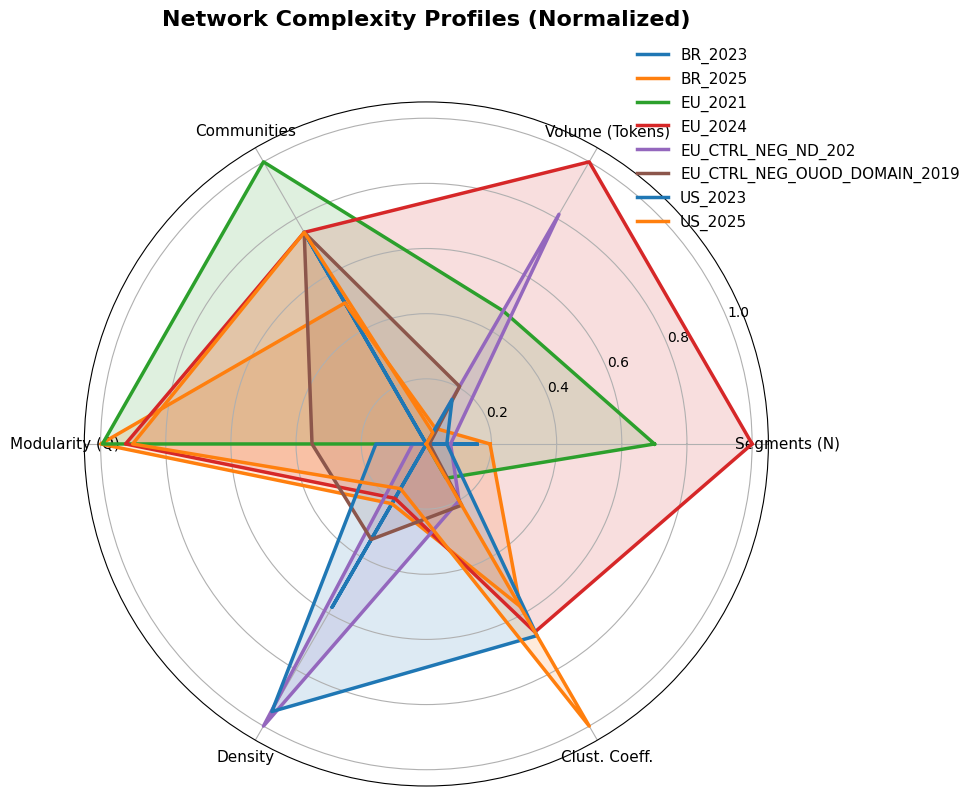

Saved: /content/corpus/outputs/radar_chart_complexity.png


In [8]:
import math
from collections import Counter
import networkx as nx
from community import community_louvain
from sklearn.preprocessing import MinMaxScaler

THRESHOLD_RATIO = 0.002
THRESHOLD_FLOOR = 3
NETWORK_TOP_TERMS = 50
NETWORK_WINDOW = 3

def compute_t_dynamic(n_tokens: int) -> int:
    return max(THRESHOLD_FLOOR, int(THRESHOLD_RATIO * n_tokens))

network_rows = []
print("Building co-occurrence networks (T_dynamic per document):")

for filepath in sorted(glob.glob(os.path.join(CORPUS_DIR, "*LIMPOS.txt"))):
    name = document_name(filepath)
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        raw_text = f.read()

    n_segments = sum(1 for p in raw_text.split("\n") if len(p.strip()) > 10)

    tokens_raw = [t.lower() for t in raw_text.split() if len(t) > 2]
    tokens = [t for t in tokens_raw if t not in NETWORK_SIMILARITY_STOPLIST]
    n_tokens = len(tokens)
    if n_tokens == 0:
        continue

    t_dynamic = compute_t_dynamic(n_tokens)
    top_terms = {w for w, _ in Counter(tokens).most_common(NETWORK_TOP_TERMS)}

    edge_weights = Counter()
    for i, word in enumerate(tokens):
        if word not in top_terms:
            continue
        window = range(max(0, i - NETWORK_WINDOW), min(len(tokens), i + NETWORK_WINDOW + 1))
        for j in window:
            if j != i and tokens[j] in top_terms:
                edge_weights[tuple(sorted((word, tokens[j])))] += 1

    graph = nx.Graph()
    for (w1, w2), weight in edge_weights.items():
        if weight >= t_dynamic:
            graph.add_edge(w1, w2, weight=weight)

    if graph.number_of_nodes() > 0:
        partition = community_louvain.best_partition(graph, weight="weight", random_state=RANDOM_SEED)
        modularity = community_louvain.modularity(partition, graph, weight="weight")
        n_communities = len(set(partition.values()))
        density = nx.density(graph)
        clustering = nx.average_clustering(graph, weight="weight")
    else:
        modularity = n_communities = density = clustering = 0

    network_rows.append({
        "Document": name, "Segments (N)": n_segments, "Volume (Tokens)": n_tokens,
        "Communities": n_communities, "Modularity (Q)": modularity,
        "Density": density, "Clust. Coeff.": clustering,
    })
    print(f"  {name:10s} | tokens={n_tokens:>7,d} | T_dynamic={t_dynamic:>4d} | communities={n_communities}")

network_metrics = pd.DataFrame(network_rows)
network_metrics.to_csv(os.path.join(OUTPUT_DIR, "network_complexity_metrics.csv"), index=False)

print("\nTable 3 -- Network complexity metrics:")
print(network_metrics.round(3).to_string(index=False))

# --- Radar chart ---------------------------------------------------------
radar_columns = ["Segments (N)", "Volume (Tokens)", "Communities", "Modularity (Q)", "Density", "Clust. Coeff."]
normalized = network_metrics.copy()
normalized[radar_columns] = MinMaxScaler().fit_transform(network_metrics[radar_columns])

angles = [n / len(radar_columns) * 2 * math.pi for n in range(len(radar_columns))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], radar_columns, size=11)
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
for i, row in normalized.iterrows():
    values = row[radar_columns].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, label=row["Document"], color=palette[i % len(palette)])
    ax.fill(angles, values, color=palette[i % len(palette)], alpha=0.15)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=False)
plt.title("Network Complexity Profiles (Normalized)", size=16, y=1.1, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "radar_chart_complexity.png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/radar_chart_complexity.png")


## Stage 6 -- Similarity Metrics (Jaccard, Dice, TF-IDF Cosine, Sentence-BERT)

Four document-pair similarity matrices, triangulating vocabulary overlap (Jaccard, Dice), weighted lexical
proximity (TF-IDF cosine), and contextual proximity (Sentence-BERT cosine). Jaccard, Dice, and Sentence-BERT
operate on whitespace-split tokens straight from the `_LIMPOS.txt` files (no additional stoplist). TF-IDF
applies `NETWORK_SIMILARITY_STOPLIST` before vectorizing -- this is the configuration that reproduces the
manuscript's reported values; an earlier, unfiltered TF-IDF pass existed in the pipeline history and produced
different numbers for the same document pairs, which is why this is called out explicitly here rather than left
implicit.

Computing Jaccard similarity...
                              BR_2023  BR_2025  EU_2021  EU_2024  \
BR_2023                         1.000    0.383    0.207    0.188   
BR_2025                         0.383    1.000    0.217    0.206   
EU_2021                         0.207    0.217    1.000    0.477   
EU_2024                         0.188    0.206    0.477    1.000   
EU_CTRL_NEG_ND_202              0.162    0.174    0.222    0.219   
EU_CTRL_NEG_OUOD_DOMAIN_2019    0.123    0.124    0.128    0.116   
US_2023                         0.189    0.209    0.207    0.208   
US_2025                         0.165    0.178    0.177    0.167   

                              EU_CTRL_NEG_ND_202  \
BR_2023                                    0.162   
BR_2025                                    0.174   
EU_2021                                    0.222   
EU_2024                                    0.219   
EU_CTRL_NEG_ND_202                         1.000   
EU_CTRL_NEG_OUOD_DOMAIN_2019               

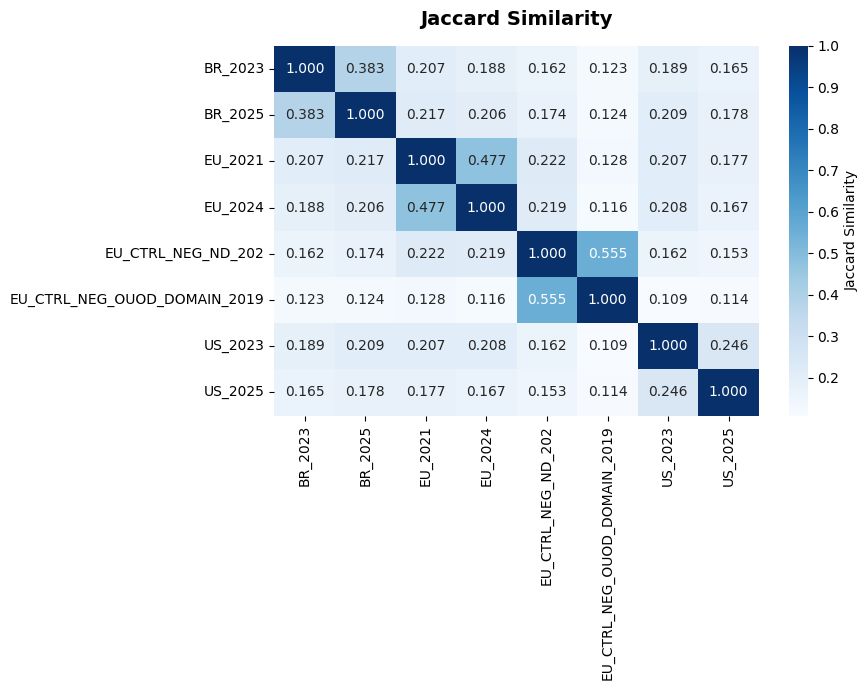


Computing Dice coefficient...
                              BR_2023  BR_2025  EU_2021  EU_2024  \
BR_2023                        1.0000   0.5535   0.3433   0.3172   
BR_2025                        0.5535   1.0000   0.3570   0.3414   
EU_2021                        0.3433   0.3570   1.0000   0.6459   
EU_2024                        0.3172   0.3414   0.6459   1.0000   
EU_CTRL_NEG_ND_202             0.2786   0.2969   0.3631   0.3591   
EU_CTRL_NEG_OUOD_DOMAIN_2019   0.2188   0.2205   0.2266   0.2086   
US_2023                        0.3174   0.3461   0.3435   0.3438   
US_2025                        0.2832   0.3028   0.3007   0.2867   

                              EU_CTRL_NEG_ND_202  \
BR_2023                                   0.2786   
BR_2025                                   0.2969   
EU_2021                                   0.3631   
EU_2024                                   0.3591   
EU_CTRL_NEG_ND_202                        1.0000   
EU_CTRL_NEG_OUOD_DOMAIN_2019              0.

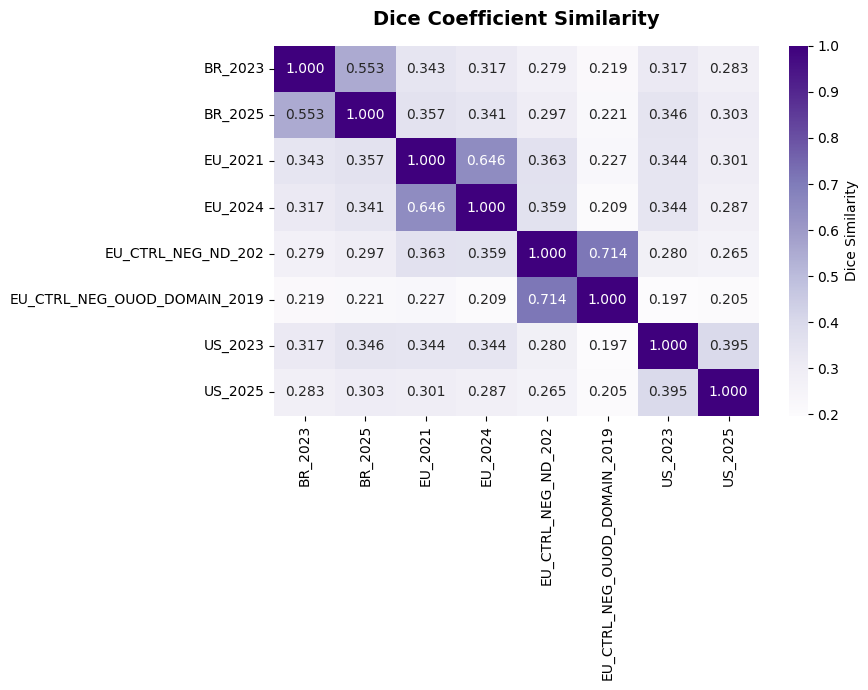


Computing TF-IDF cosine similarity...
                              BR_2023  BR_2025  EU_2021  EU_2024  \
BR_2023                         1.000    0.677    0.467    0.395   
BR_2025                         0.677    1.000    0.539    0.532   
EU_2021                         0.467    0.539    1.000    0.915   
EU_2024                         0.395    0.532    0.915    1.000   
EU_CTRL_NEG_ND_202              0.226    0.274    0.317    0.321   
EU_CTRL_NEG_OUOD_DOMAIN_2019    0.062    0.083    0.120    0.121   
US_2023                         0.269    0.333    0.261    0.267   
US_2025                         0.244    0.283    0.236    0.226   

                              EU_CTRL_NEG_ND_202  \
BR_2023                                    0.226   
BR_2025                                    0.274   
EU_2021                                    0.317   
EU_2024                                    0.321   
EU_CTRL_NEG_ND_202                         1.000   
EU_CTRL_NEG_OUOD_DOMAIN_2019        

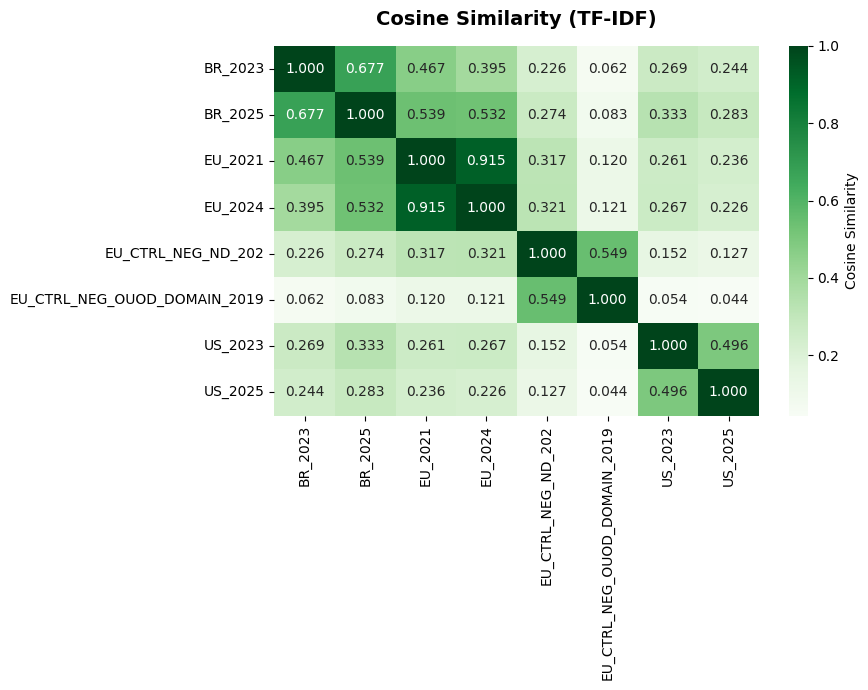


Computing Sentence-BERT cosine similarity (all-MiniLM-L6-v2)...
Note: Using Segment-level Mean Pooling to overcome the 256-token limit. Each document is embedded segment-by-segment and averaged to capture full semantic depth.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Matriz SBERT (Mean Pooling):
                              BR_2023  BR_2025  EU_2021  EU_2024  \
BR_2023                        1.0000   0.9771   0.9159   0.9289   
BR_2025                        0.9771   1.0000   0.9204   0.9459   
EU_2021                        0.9159   0.9204   1.0000   0.9698   
EU_2024                        0.9289   0.9459   0.9698   1.0000   
EU_CTRL_NEG_ND_202             0.7397   0.7603   0.7485   0.7829   
EU_CTRL_NEG_OUOD_DOMAIN_2019   0.6002   0.6209   0.6271   0.6401   
US_2023                        0.8234   0.8547   0.8154   0.8665   
US_2025                        0.7257   0.7509   0.7220   0.7550   

                              EU_CTRL_NEG_ND_202  \
BR_2023                                   0.7397   
BR_2025                                   0.7603   
EU_2021                                   0.7485   
EU_2024                                   0.7829   
EU_CTRL_NEG_ND_202                        1.0000   
EU_CTRL_NEG_OUOD_DOMAIN_2019              0.8

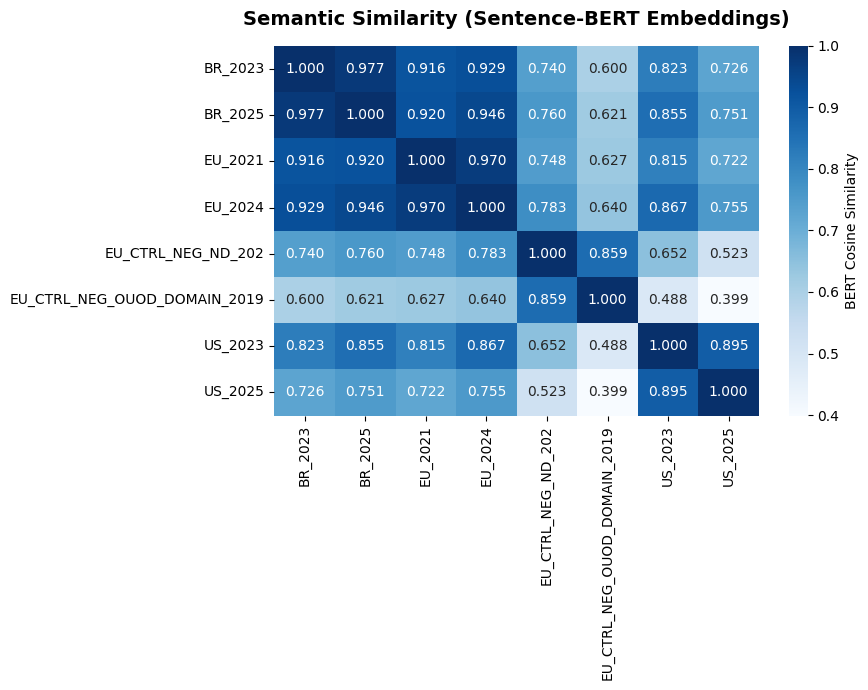

In [12]:
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

def load_full_documents(corpus_dir):
    docs = {}
    for filepath in sorted(glob.glob(os.path.join(corpus_dir, "*LIMPOS.txt"))):
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            docs[document_name(filepath)] = f.read()
    return docs

full_documents = load_full_documents(CORPUS_DIR)
doc_ids = sorted(full_documents.keys())

def save_similarity_heatmap(df, title, filename, cmap, label):
    plt.figure(figsize=(9, 7))
    sns.heatmap(df, annot=True, fmt=".3f", cmap=cmap, cbar_kws={"label": label})
    plt.title(title, fontsize=14, pad=15, fontweight="bold")
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()

# --- 6a. Jaccard ----------------------------------------------------------
print("Computing Jaccard similarity...")
doc_token_sets = {d: set(full_documents[d].lower().split()) for d in doc_ids}
jaccard_df = pd.DataFrame(index=doc_ids, columns=doc_ids, dtype=float)
for d1 in doc_ids:
    for d2 in doc_ids:
        union = doc_token_sets[d1] | doc_token_sets[d2]
        jaccard_df.loc[d1, d2] = round(len(doc_token_sets[d1] & doc_token_sets[d2]) / len(union), 3) if union else 0.0
print(jaccard_df)
jaccard_df.to_csv(os.path.join(OUTPUT_DIR, "matriz_jaccard_6x6.csv"))
save_similarity_heatmap(jaccard_df, "Jaccard Similarity", "heatmap_jaccard.png", "Blues", "Jaccard Similarity")

# --- 6b. Dice ---------------------------------------------------------
print("\nComputing Dice coefficient...")
dice_df = pd.DataFrame(index=doc_ids, columns=doc_ids, dtype=float)
for d1 in doc_ids:
    for d2 in doc_ids:
        s1, s2 = doc_token_sets[d1], doc_token_sets[d2]
        total = len(s1) + len(s2)
        dice_df.loc[d1, d2] = round((2 * len(s1 & s2)) / total, 4) if total else 0.0
print(dice_df)
dice_df.to_csv(os.path.join(OUTPUT_DIR, "matriz_dice_6x6.csv"))
save_similarity_heatmap(dice_df, "Dice Coefficient Similarity", "heatmap_dice_english.png", "Purples", "Dice Similarity")

# --- 6c. TF-IDF Cosine ------------------------------------------------
print("\nComputing TF-IDF cosine similarity...")
tfidf_texts = []
for d in doc_ids:
    tokens = [t.lower() for t in full_documents[d].split() if t.lower() not in NETWORK_SIMILARITY_STOPLIST and len(t) > 2]
    tfidf_texts.append(" ".join(tokens))

tfidf_matrix = TfidfVectorizer().fit_transform(tfidf_texts)
tfidf_df = pd.DataFrame(cosine_similarity(tfidf_matrix), index=doc_ids, columns=doc_ids).round(3)
print(tfidf_df)
tfidf_df.to_csv(os.path.join(OUTPUT_DIR, "matriz_cosseno_tfidf_6x6.csv"))
save_similarity_heatmap(tfidf_df, "Cosine Similarity (TF-IDF)", "heatmap_tfidf.png", "Greens", "Cosine Similarity")

# --- 6d. Sentence-BERT --------------------------------------------------
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
# Certifique-se de que o SentenceTransformer e o pandas já estejam importados no topo do seu script

print("\nComputing Sentence-BERT cosine similarity (all-MiniLM-L6-v2)...")
print("Note: Using Segment-level Mean Pooling to overcome the 256-token limit. "
      "Each document is embedded segment-by-segment and averaged to capture full semantic depth.")

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
doc_embeddings = []

# Iterando sobre cada documento para fazer o Mean Pooling
for d in doc_ids:
    text = full_documents[d]

    # 1. Separa o documento limpo em segmentos (presumindo que cada parágrafo/artigo é uma linha)
    segmentos = [seg for seg in text.split('\n') if seg.strip()]

    # Prevenção contra documentos acidentalmente vazios
    if not segmentos:
        doc_embeddings.append(np.zeros(384)) # Dimensão padrão do all-MiniLM-L6-v2
        continue

    # 2. Gera os vetores para cada segmento separadamente (nada é truncado)
    seg_embs = sbert_model.encode(segmentos, show_progress_bar=False)

    # 3. Tira a média matemática de todos os segmentos para gerar o vetor do documento inteiro
    doc_emb = np.mean(seg_embs, axis=0)
    doc_embeddings.append(doc_emb)

# Converte a lista em uma matriz numpy e calcula a similaridade do cosseno global
embeddings_array = np.array(doc_embeddings)
bert_matrix = cosine_similarity(embeddings_array)

# Cria o DataFrame e arredonda para 4 casas decimais
bert_df = pd.DataFrame(bert_matrix, index=doc_ids, columns=doc_ids).round(4)
print("\nMatriz SBERT (Mean Pooling):")
print(bert_df)

# Exportações originais da sua pipeline
bert_df.to_csv(os.path.join(OUTPUT_DIR, "matriz_bert_cosine_6x6.csv"))
save_similarity_heatmap(
    bert_df,
    "Semantic Similarity (Sentence-BERT Embeddings)",
    "heatmap_bert_english.png",
    "Blues",
    "BERT Cosine Similarity"
)

## Stage 7 -- Package Outputs

Runs **last**, after every stage above has produced its artefacts. Zips `outputs/` and triggers a download.
(In the original notebook this step ran before the final similarity-matrix cell, so the downloaded archive
silently excluded Stage 6's outputs on a straight top-to-bottom run -- fixed here by ordering.)

In [14]:
import shutil

archive_path = shutil.make_archive("/content/outputs", "zip", OUTPUT_DIR)
print(f"Archive created: {archive_path}")
print(f"Contents: {sorted(os.listdir(OUTPUT_DIR))}")

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Not running in Colab -- skipping browser download; the archive is available at the path above.")


Archive created: /content/outputs.zip
Contents: ['heatmap_bert_english.png', 'heatmap_dice_english.png', 'heatmap_jaccard.png', 'heatmap_tfidf.png', 'lda_metrics_combined.png', 'matriz_bert_cosine_6x6.csv', 'matriz_cosseno_tfidf_6x6.csv', 'matriz_dice_6x6.csv', 'matriz_jaccard_6x6.csv', 'network_complexity_metrics.csv', 'prominencia_lexical_dirigida.csv', 'radar_chart_complexity.png', 'resultado_estabilidade_lda.txt', 'sankey_diagram.html', 'wordclouds_lda.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>